# 🎯 Discovering Embeddings - Text as Vectors!

## 🤔 What Are Embeddings?

Imagine teaching a computer to understand language by converting words and sentences into **mathematical vectors**!

**The Magic:** 
- 📝 "The cat is sleeping" → `[0.23, -0.45, 0.87, ...]` (384 numbers!)
- 🧠 Similar meanings → Similar vectors
- 🎯 Can measure semantic similarity mathematically

---

### 🌟 Why Embeddings Are Revolutionary:

| Traditional Approach | Embeddings Approach |
|---------------------|---------------------|
| 🔤 Words as strings | 🔢 Words as vectors |
| ❌ Can't compare meanings | ✅ Can measure similarity |
| 🚫 No semantic understanding | 🧠 Captures meaning & context |
| 📏 Fixed vocabulary | 🌐 Handles any text |

---

### 🎓 What You'll Learn:

1. 🤖 **Load pre-trained models** - Use powerful sentence transformers
2. 🔄 **Convert text to vectors** - See embeddings in action
3. 📊 **Measure similarity** - Compare semantic meaning
4. 🎨 **Visualize embeddings** - See language in 2D space
5. 💡 **Real applications** - Discover practical use cases

Let's dive in! 🚀

### 📦 The Model We'll Use:

**`text-embedding-3-small`**
- Supports multiple languages (English, French, Spanish, etc.)
- Creates 1536-dimensional vectors
- Optimized for semantic similarity tasks
- Perfect balance of speed and accuracy


- 🌍 **Multilingual:** Works in 50+ languages
- ⚡ **Fast:** Encodes sentences in seconds
- 🎯 **Accurate:** State-of-the-art semantic understanding

Let's load it!

In [ ]:
import os

from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings

# Load the pre-trained model
load_dotenv()
os.environ["OPENAI_API_KEY"] = (
    ""
)

# Initialize the embedding model

embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    # With the `text-embedding-3` class
    # of models, you can specify the size
    # of the embeddings you want returned.
    # dimensions=1024  # noqa: ERA001
)


print("✅ Model loaded successfully!")
print("   Model can handle: Multiple languages")
print("   Embedding dimension: 1536")
print("   Ready to convert text to vectors! 🚀")


✅ Model loaded successfully!
   Model can handle: Multiple languages
   Embedding dimension: 1536
   Ready to convert text to vectors! 🚀


In [2]:
from langchain_core.embeddings import Embeddings


# 🔄 Creating Your First Embedding
def embed(text: str) -> list[float]:
    """Convert a text string into a vector embedding using the pre-trained model."""
    return embedding_model.embed_query(text)



class EmbeddingsTest(Embeddings):
    """Test class to implement the Embeddings interface using the OpenAIEmbeddings model."""

    def embed_query(self, text: str) -> list[float]:
        """Embed a single query string into a vector."""
        return embedding_model.embed_query(text)

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        """Embed a list of documents into vectors."""
        return embedding_model.embed_documents(texts)


e = EmbeddingsTest()


In [3]:
from langchain_core.embeddings import Embeddings

Embeddings


langchain_core.embeddings.embeddings.Embeddings

In [4]:
OpenAIEmbeddings


langchain_openai.embeddings.base.OpenAIEmbeddings

---

# 🔄 Creating Your First Embedding

Let's convert a simple sentence into a vector!

In [5]:
# Our input sentence
input_str = "The weather is beautiful"

# Convert to embedding (vector)
embedding = embedding_model.embed_query(input_str)

print(f"📝 Input sentence: '{input_str}'")
print("\n🔢 Embedding (vector representation):")
print(f"   First 10 values: {embedding[:10]}")
print("   ...")
print(f"   Last 10 values: {embedding[-10:]}")
print("\n📊 Each number captures different semantic aspects!")


📝 Input sentence: 'The weather is beautiful'

🔢 Embedding (vector representation):
   First 10 values: [0.010934686288237572, -0.027822494506835938, -0.011565890163183212, 0.010940873995423317, 0.026065023615956306, -0.01712915115058422, 0.0015609929105266929, -0.011058451607823372, -0.025891752913594246, -0.011293605901300907]
   ...
   Last 10 values: [0.026461074128746986, 0.011702032759785652, 0.0010303481249138713, -0.006079982500523329, 0.020446067675948143, 0.057130176573991776, -0.004919680301100016, -0.034307811409235, 0.0036139539442956448, 0.013304796069860458]

📊 Each number captures different semantic aspects!


In [6]:
# Check the dimension
dimension = len(embedding)

print(f"📏 Embedding dimension: {dimension}")
print(f"\n💡 This means our sentence is represented by {dimension} numbers!")
print("   Each dimension captures different aspects of meaning:")
print("   • Some dimensions might encode 'weather' concepts")
print("   • Others might encode positive sentiment")
print("   • Together, they form a unique 'fingerprint' of the sentence")


📏 Embedding dimension: 1536

💡 This means our sentence is represented by 1536 numbers!
   Each dimension captures different aspects of meaning:
   • Some dimensions might encode 'weather' concepts
   • Others might encode positive sentiment
   • Together, they form a unique 'fingerprint' of the sentence


---

# 📊 Measuring Similarity

Now for the **magic** - let's compare multiple sentences and see which ones are semantically similar!

## 🧪 The Experiment:

We'll compare three sentences:
1. "The weather is lovely today" 🌞
2. "It's so sunny outside!" ☀️
3. "He drove to the stadium" 🚗

**Prediction:** Sentences 1 & 2 should be similar (both about weather), while 3 should be different.

Let's test this!

In [7]:
import numpy as np

# Our test sentences
inputs = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

print("🔄 Converting sentences to embeddings...")
embeddings = embedding_model.embed_documents(inputs)

print("📊 Computing similarity matrix...")
embeddings = np.array(embeddings)
similarities = np.dot(embeddings, embeddings.T)

print("\n✅ Complete! Let's visualize the results...")
print(f"\n📐 Similarity matrix shape: {similarities.shape}")
print("   (3 sentences x 3 sentences = 9 similarity scores)")


🔄 Converting sentences to embeddings...
📊 Computing similarity matrix...

✅ Complete! Let's visualize the results...

📐 Similarity matrix shape: (3, 3)
   (3 sentences x 3 sentences = 9 similarity scores)


## 🎨 Creating a Visualization Function

Let's make a beautiful heatmap to visualize similarities!

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print(np.__version__)

def compute_and_display_similarities(inputs: list[str], title: str = "Semantic Similarity Heatmap") -> None:
    """Compute and display a beautiful heatmap of sentence similarities.

    Args:
        inputs: List of sentences to compare
        title: Title for the plot

    """
    # Compute embeddings and similarities
    embeddings = embedding_model.embed_documents(inputs)
    embeddings = np.array(embeddings)
    similarities = np.dot(embeddings, embeddings.T)

    # Create figure
    plt.figure(figsize=(12, 10))

    # Create heatmap
    _ax = sns.heatmap(
        similarities,
        annot=True,  # Show values
        fmt=".3f",  # 3 decimal places
        xticklabels=inputs,
        yticklabels=inputs,
        cmap="YlGnBu",  # Yellow-Green-Blue colormap
        cbar_kws={"label": "Similarity Score"},
        vmin=0,  # Minimum value
        vmax=1,  # Maximum value
        square=True,  # Square cells
        linewidths=0.5,  # Grid lines
        linecolor="gray",
    )

    # Styling
    plt.title(title, fontsize=16, fontweight="bold", pad=20)
    plt.xlabel("Sentences", fontsize=12, fontweight="bold")
    plt.ylabel("Sentences", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Print interpretation
    print("\n📖 How to read this heatmap:")
    print("   • 1.0 (dark blue) = Perfect similarity (same sentence)")
    print("   • 0.8-0.9 = Very similar meaning")
    print("   • 0.5-0.7 = Somewhat related")
    print("   • 0.0-0.4 = Different meanings")
    print("   • 0.0 (light yellow) = Completely different")


print("✅ Visualization function created!")


2.3.5
✅ Visualization function created!


🎨 Generating similarity heatmap...



/var/folders/tp/_ld5_pzs6nx6mv1pbjhq1l740000gn/T/ipykernel_24511/1064958240.py:45: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


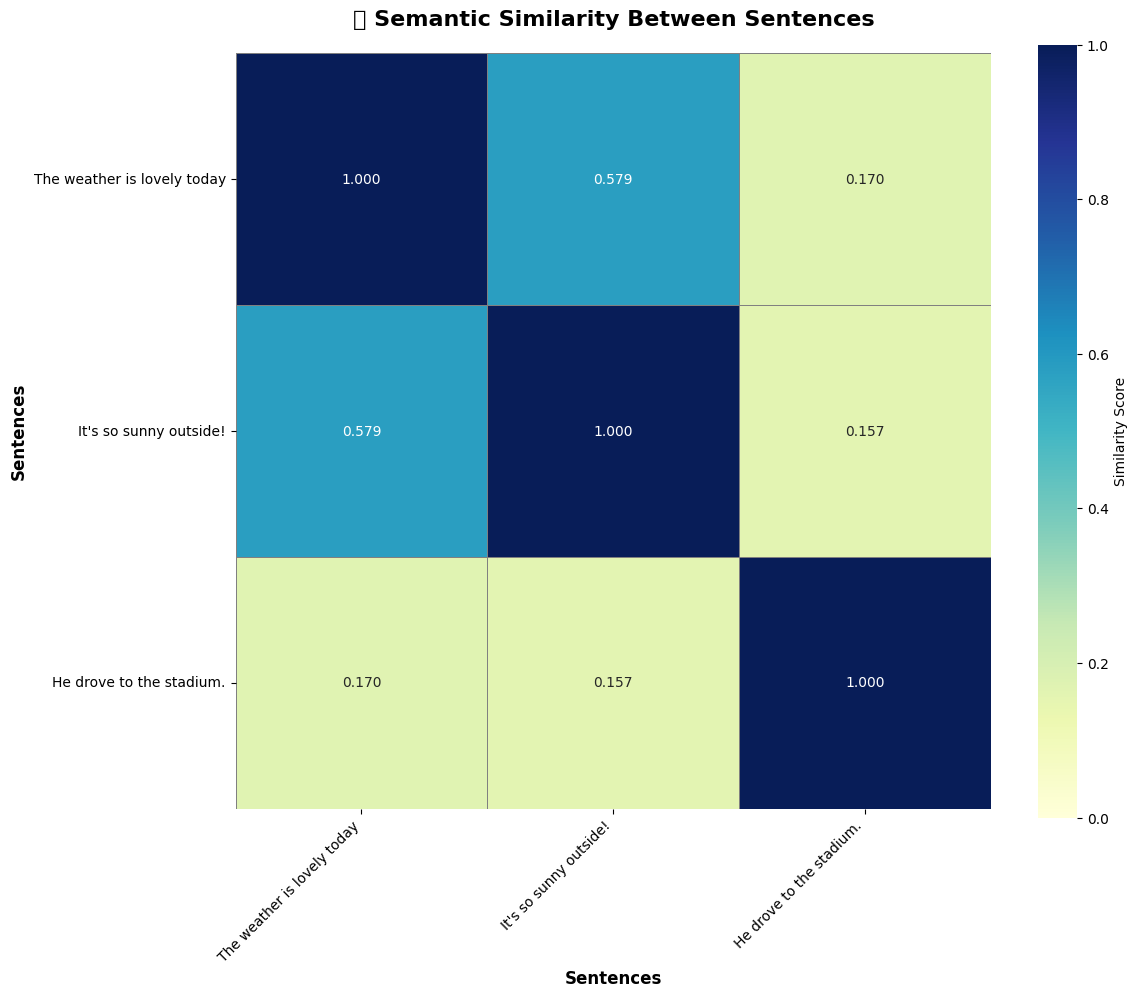


📖 How to read this heatmap:
   • 1.0 (dark blue) = Perfect similarity (same sentence)
   • 0.8-0.9 = Very similar meaning
   • 0.5-0.7 = Somewhat related
   • 0.0-0.4 = Different meanings
   • 0.0 (light yellow) = Completely different

🔍 Observations:
   ✅ Sentences 1 & 2 have HIGH similarity (both about weather)
   ❌ Sentence 3 has LOW similarity with others (different topic)
   🎯 The model understands semantic meaning, not just word matching!


In [9]:
# Test with our sentences
inputs = [
    "The weather is lovely today",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

print("🎨 Generating similarity heatmap...\n")
compute_and_display_similarities(inputs, "🌟 Semantic Similarity Between Sentences")

print("\n🔍 Observations:")
print("   ✅ Sentences 1 & 2 have HIGH similarity (both about weather)")
print("   ❌ Sentence 3 has LOW similarity with others (different topic)")
print("   🎯 The model understands semantic meaning, not just word matching!")


### 🌍 Multilingual Magic!

Our model works across languages! Let's test with French and English:

🌍 Testing multilingual understanding...



/var/folders/tp/_ld5_pzs6nx6mv1pbjhq1l740000gn/T/ipykernel_24511/1064958240.py:45: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


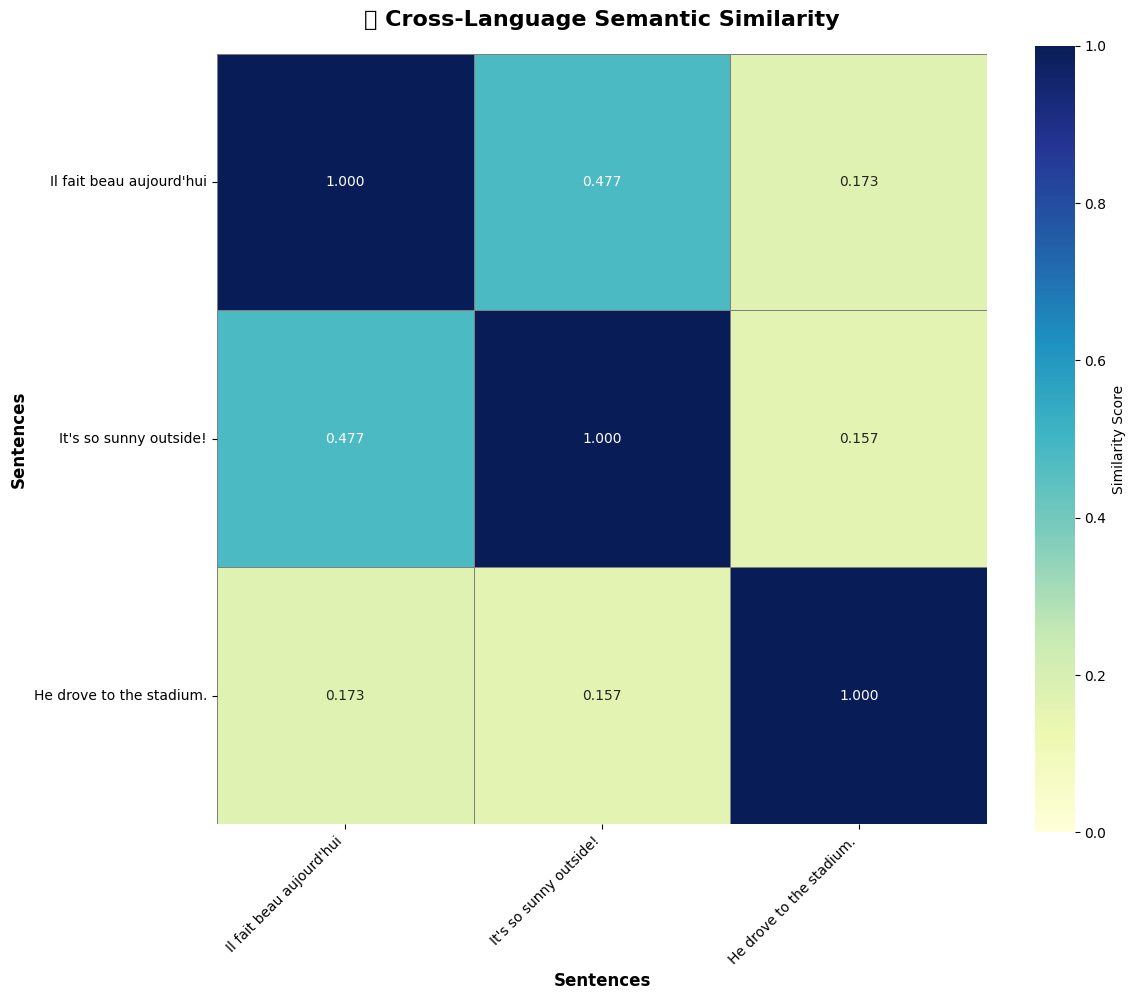


📖 How to read this heatmap:
   • 1.0 (dark blue) = Perfect similarity (same sentence)
   • 0.8-0.9 = Very similar meaning
   • 0.5-0.7 = Somewhat related
   • 0.0-0.4 = Different meanings
   • 0.0 (light yellow) = Completely different

🤯 Amazing! The model recognizes that:
   • French 'Il fait beau' ≈ English 'sunny outside'
   • Despite different languages, it captures the SAME meaning!
   • This is the power of multilingual embeddings! 🚀


In [10]:
# Mix French and English!
multilingual_inputs = [
    "Il fait beau aujourd'hui",  # French: "The weather is nice today"
    "It's so sunny outside!",  # English
    "He drove to the stadium.",  # English (different topic)
]

print("🌍 Testing multilingual understanding...\n")
compute_and_display_similarities(
    multilingual_inputs, "🌐 Cross-Language Semantic Similarity",
)

print("\n🤯 Amazing! The model recognizes that:")
print("   • French 'Il fait beau' ≈ English 'sunny outside'")
print("   • Despite different languages, it captures the SAME meaning!")
print("   • This is the power of multilingual embeddings! 🚀")


---

# 🧪 Hands-On Exercise: Understanding Similarity Metrics

## 🎯 Goal

Explore how **cosine similarity** and **Euclidean distance** behave with embeddings.

### 📐 Two Ways to Compare Vectors:

| Metric | Formula | What it measures |
|--------|---------|------------------|
| **Cosine Similarity** | $\frac{u \cdot v}{\|u\| \|v\|}$ | Angle between vectors (0-1) |
| **Euclidean Distance** | $\|u - v\|$ | Straight-line distance |

---

### 🤔 Why Does This Matter?

**Cosine similarity** is preferred for text because:
- 🎯 Focuses on **direction** (meaning) not magnitude (length)
- 📏 Normalized to 0-1 range (easy to interpret)
- 🎨 More robust to text length variations

Let's see this in action!

## 🔧 Implementing Similarity Functions

In [11]:
import numpy as np


def cosine_similarity(u: list[float] | np.ndarray, v: list[float] | np.ndarray) -> float:
    """Calculate cosine similarity between two vectors.

    Returns a value between 0 and 1:
    - 1.0 = vectors point in same direction (very similar)
    - 0.0 = vectors are perpendicular (unrelated)
    """
    u, v = np.array(u), np.array(v)
    # Normalize vectors to unit length
    u_norm = u / np.linalg.norm(u)
    v_norm = v / np.linalg.norm(v)
    # Dot product of normalized vectors
    return float(u_norm @ v_norm)


def euclidean_distance(u: list[float] | np.ndarray, v: list[float] | np.ndarray) -> float:
    """Calculate Euclidean distance between two vectors.

    Returns the straight-line distance:
    - 0.0 = identical vectors
    - Larger values = more different
    """
    u, v = np.array(u), np.array(v)
    return float(np.linalg.norm(u - v))


print("✅ Similarity functions defined!")
print("\n📊 Available metrics:")
print("   1. cosine_similarity(u, v) → 0 to 1 (higher = more similar)")
print("   2. euclidean_distance(u, v) → 0 to ∞ (lower = more similar)")


✅ Similarity functions defined!

📊 Available metrics:
   1. cosine_similarity(u, v) → 0 to 1 (higher = more similar)
   2. euclidean_distance(u, v) → 0 to ∞ (lower = more similar)


## 🐱 Test Sentences: The Cat Family

We'll compare three sentences of increasing length, all about cats:

In [12]:
# Three sentences about cats, with increasing detail
phrase_chat_1 = "the cat is a feline"
phrase_chat_2 = "the cat is a feline, the cat is a feline"
phrase_chat_3 = (
    "the cat is a feline, the cat is a feline, the cat is a feline, the cat is a feline"
)

print("🐱 Our test sentences:\n")
print(f"1️⃣  SHORT: '{phrase_chat_1}'")
print(f"    Length: {len(phrase_chat_1)} characters\n")

print(f"2️⃣  MEDIUM: '{phrase_chat_2}'")
print(f"    Length: {len(phrase_chat_2)} characters\n")

print(f"3️⃣  LONG: '{phrase_chat_3}'")
print(f"    Length: {len(phrase_chat_3)} characters\n")

print("💡 All three sentences are about cats, but with different lengths!")


🐱 Our test sentences:

1️⃣  SHORT: 'the cat is a feline'
    Length: 19 characters

2️⃣  MEDIUM: 'the cat is a feline, the cat is a feline'
    Length: 40 characters

3️⃣  LONG: 'the cat is a feline, the cat is a feline, the cat is a feline, the cat is a feline'
    Length: 82 characters

💡 All three sentences are about cats, but with different lengths!


In [13]:
# Generate embeddings
print("🔄 Converting sentences to embeddings...\n")

phrase_chat_1_emb = embedding_model.embed_query(phrase_chat_1)
phrase_chat_2_emb = embedding_model.embed_query(phrase_chat_2)
phrase_chat_3_emb = embedding_model.embed_query(phrase_chat_3)

print("✅ Embeddings created!")
print(f"   Each is a {len(phrase_chat_1_emb)}-dimensional vector")


🔄 Converting sentences to embeddings...

✅ Embeddings created!
   Each is a 1536-dimensional vector


---

## 📏 Task 1: Calculate Euclidean Distance

Now let's compare using **Euclidean distance**.

**What to expect:** Lower values mean more similar!

In [14]:
# Calculate all pairwise Euclidean distances
print("📏 Euclidean Distance Results:\n")
print("=" * 60)


# Sentence 1 vs Sentence 3
dist_1_3 = euclidean_distance(phrase_chat_1_emb, phrase_chat_3_emb)
print(f"📐 Short vs Long:    {dist_1_3:.4f}")

dist_1_2 = euclidean_distance(phrase_chat_1_emb, phrase_chat_2_emb)
print(f"📐 Short vs Medium:  {dist_1_2:.4f}")

# Sentence 2 vs Sentence 3
dist_2_3 = euclidean_distance(phrase_chat_2_emb, phrase_chat_3_emb)
print(f"📐 Medium vs Long:   {dist_2_3:.4f}")

print("=" * 60)

# Analysis
print("\n🔍 Observations:")
print("   • Distances INCREASE with text length difference")
print(f"   • Short vs Long has LARGEST distance: {dist_1_3:.4f}")
print(f"   • Medium vs Long has SMALLEST distance: {dist_2_3:.4f}")
print("\n⚠️  Problem: Euclidean distance is affected by vector magnitude!")
print("   Longer texts → larger vectors → larger distances")
print("   Even if the MEANING is similar!")


📏 Euclidean Distance Results:

📐 Short vs Long:    0.5506
📐 Short vs Medium:  0.4474
📐 Medium vs Long:   0.3820

🔍 Observations:
   • Distances INCREASE with text length difference
   • Short vs Long has LARGEST distance: 0.5506
   • Medium vs Long has SMALLEST distance: 0.3820

⚠️  Problem: Euclidean distance is affected by vector magnitude!
   Longer texts → larger vectors → larger distances
   Even if the MEANING is similar!


---

## 📊 Task 2: Calculate Cosine Similarity

Compare each pair of sentences using **cosine similarity**.

**What to expect:** Values close to 1 mean very similar meanings!

In [15]:
# Calculate all pairwise cosine similarities
print("📊 Cosine Similarity Results:\n")
print("=" * 60)

# Sentence 1 vs Sentence 2
sim_1_2 = cosine_similarity(phrase_chat_1_emb, phrase_chat_2_emb)
print(f"🐱 Short vs Medium:  {sim_1_2:.4f}")

# Sentence 1 vs Sentence 3
sim_1_3 = cosine_similarity(phrase_chat_1_emb, phrase_chat_3_emb)
print(f"🐱 Short vs Long:    {sim_1_3:.4f}")

# Sentence 2 vs Sentence 3
sim_2_3 = cosine_similarity(phrase_chat_2_emb, phrase_chat_3_emb)
print(f"🐱 Medium vs Long:   {sim_2_3:.4f}")

print("=" * 60)

# Analysis
print("\n🔍 Observations:")
avg_similarity = (sim_1_2 + sim_1_3 + sim_2_3) / 3
print(f"   • Average similarity: {avg_similarity:.4f}")
print("   • All values are HIGH (close to 1.0)")
print("   • The model recognizes they're all about CATS! 🐱")
print("   • Text length doesn't drastically affect similarity")
print("\n💡 Cosine similarity focuses on MEANING, not LENGTH!")


📊 Cosine Similarity Results:

🐱 Short vs Medium:  0.8999
🐱 Short vs Long:    0.8484
🐱 Medium vs Long:   0.9270

🔍 Observations:
   • Average similarity: 0.8918
   • All values are HIGH (close to 1.0)
   • The model recognizes they're all about CATS! 🐱
   • Text length doesn't drastically affect similarity

💡 Cosine similarity focuses on MEANING, not LENGTH!


---

## 🤔 Task 3: Why Cosine Similarity?

### 💡 Key Insight:

Let's compare the two metrics side by side:

In [16]:
import pandas as pd

# Create comparison table
comparison_data = {
    "Comparison": ["Short vs Medium", "Short vs Long", "Medium vs Long"],
    "Cosine Similarity": [f"{sim_1_2:.4f}", f"{sim_1_3:.4f}", f"{sim_2_3:.4f}"],
    "Euclidean Distance": [f"{dist_1_2:.4f}", f"{dist_1_3:.4f}", f"{dist_2_3:.4f}"],
}

df = pd.DataFrame(comparison_data)
print("📊 Metric Comparison:\n")
print(df.to_string(index=False))

print("\n" + "=" * 70)
print("🎯 CONCLUSION: Why Cosine Similarity Wins for Text")
print("=" * 70)

print("\n✅ Cosine Similarity Advantages:")
print("   1. 📐 Length-invariant: Not affected by text length")
print("   2. 🎯 Semantic focus: Measures meaning, not magnitude")
print("   3. 📊 Normalized: Always between 0 and 1 (easy to interpret)")
print("   4. 🔄 Consistent: Similar meanings = similar scores")

print("\n❌ Euclidean Distance Disadvantages:")
print("   1. 📏 Length-sensitive: Longer texts → larger distances")
print("   2. 🎭 Misleading: Can be large even for similar meanings")
print("   3. ⚖️ Not normalized: Hard to interpret absolute values")
print("   4. 📉 Inconsistent: Same meaning, different distance based on length")

print("\n🌟 This is why NLP systems use COSINE SIMILARITY! 🌟")


📊 Metric Comparison:

     Comparison Cosine Similarity Euclidean Distance
Short vs Medium            0.8999             0.4474
  Short vs Long            0.8484             0.5506
 Medium vs Long            0.9270             0.3820

🎯 CONCLUSION: Why Cosine Similarity Wins for Text

✅ Cosine Similarity Advantages:
   1. 📐 Length-invariant: Not affected by text length
   2. 🎯 Semantic focus: Measures meaning, not magnitude
   3. 📊 Normalized: Always between 0 and 1 (easy to interpret)
   4. 🔄 Consistent: Similar meanings = similar scores

❌ Euclidean Distance Disadvantages:
   1. 📏 Length-sensitive: Longer texts → larger distances
   2. 🎭 Misleading: Can be large even for similar meanings
   3. ⚖️ Not normalized: Hard to interpret absolute values
   4. 📉 Inconsistent: Same meaning, different distance based on length

🌟 This is why NLP systems use COSINE SIMILARITY! 🌟


---

# 🎨 Visualizing Embeddings in 2D

## 🤯 The Challenge

Our embeddings have **384 dimensions** - impossible to visualize directly!

**Solution:** Use **UMAP** (Uniform Manifold Approximation and Projection)
- 🎯 Reduces 384D → 2D while preserving relationships
- 🎨 Keeps similar items close together
- 👀 Makes patterns visible to human eyes

---

## 🧪 The Experiment

We'll embed words from **two different domains**:
- 🐾 **Animals:** Cat, Dog, Elephant, Tiger, Lion
- 💻 **Technology:** Phone, Antenna, Modem, Router, Cable

**Hypothesis:** Words from the same domain should cluster together!

In [17]:
# Our test words
elements = [
    # Animals
    "Cat",
    "Dog",
    "Elephant",
    "Tiger",
    "Lion",
    # Technology
    "Phone",
    "Antenna",
    "Modem",
    "Router",
    "Cable",
]

# Categories for coloring
categories = [
    "Animals",
    "Animals",
    "Animals",
    "Animals",
    "Animals",
    "Technology",
    "Technology",
    "Technology",
    "Technology",
    "Technology",
]

print("📋 Test Words:")
print("\n🐾 Animals:")
print("   " + ", ".join(elements[:5]))
print("\n💻 Technology:")
print("   " + ", ".join(elements[5:]))
print("\n🎯 Goal: See if embeddings naturally separate these domains!")


📋 Test Words:

🐾 Animals:
   Cat, Dog, Elephant, Tiger, Lion

💻 Technology:
   Phone, Antenna, Modem, Router, Cable

🎯 Goal: See if embeddings naturally separate these domains!


🔄 Step 1: Creating 1536D embeddings...
   ✅ Created 10 embeddings of 1536 dimensions each

📉 Step 2: Reducing 1536D → 2D with UMAP...


/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✅ Reduced to 2D coordinates

🎨 Step 3: Creating visualization...



/var/folders/tp/_ld5_pzs6nx6mv1pbjhq1l740000gn/T/ipykernel_24511/980470006.py:68: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


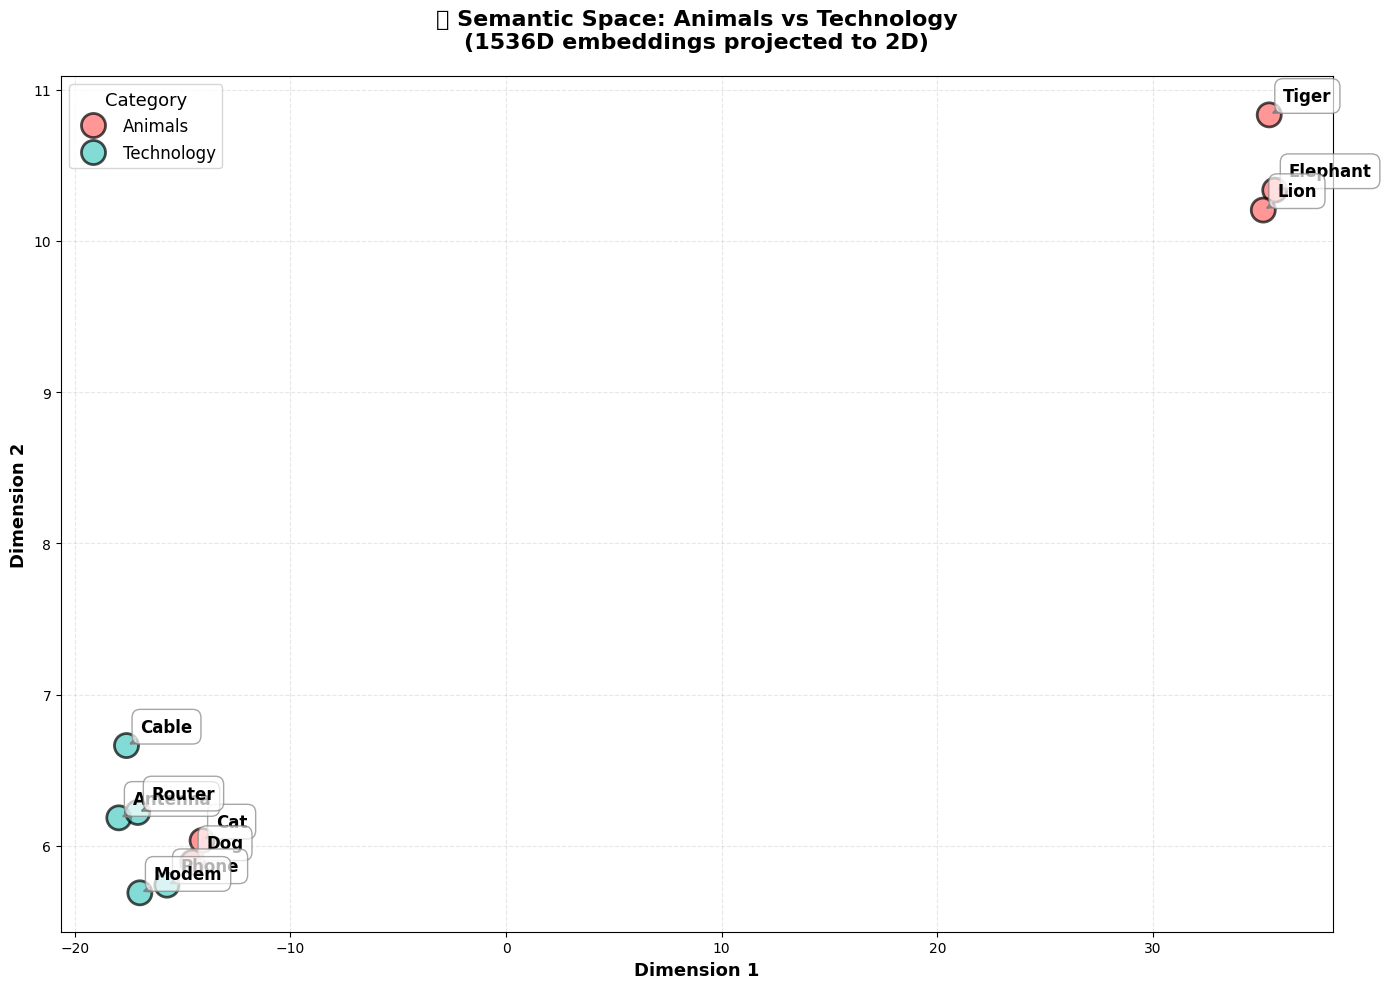


🔍 Analysis:
   🐾 RED cluster = Animals (Cat, Dog, Elephant, Tiger, Lion)
   💻 TEAL cluster = Technology (Phone, Modem, Router, etc.)

✨ Magic Observation:
   • The model AUTOMATICALLY groups related concepts together!
   • No human told it that 'Cat' and 'Dog' are related
   • It learned these relationships from massive text data
   • This is the power of embeddings! 🚀

💡 Why This Matters:
   1. Search: Find similar items even with different words
   2. Clustering: Automatically group related content
   3. Recommendations: Suggest similar items
   4. Classification: Categorize new content


In [18]:
import umap

rng = np.random.default_rng(42)
# Set random seed for reproducibilit

print("🔄 Step 1: Creating 1536D embeddings...")
embeddings_1536d = embedding_model.embed_documents(elements)
print(
    f"   ✅ Created {len(embeddings_1536d)} embeddings of {len(embeddings_1536d[0])} dimensions each",
)

print("\n📉 Step 2: Reducing 1536D → 2D with UMAP...")
reducer = umap.UMAP(
    n_neighbors=3,  # Local neighborhood size
    min_dist=0.1,  # Minimum distance between points
    metric="cosine",  # Use cosine similarity
    random_state=42,
)
embeddings_2d = reducer.fit_transform(embeddings_1536d)
print("   ✅ Reduced to 2D coordinates")

print("\n🎨 Step 3: Creating visualization...\n")

# Create beautiful plot
plt.figure(figsize=(14, 10))

# Scatter plot with categories
scatter = sns.scatterplot(
    x=embeddings_2d[:, 0],
    y=embeddings_2d[:, 1],
    hue=categories,
    palette=["#FF6B6B", "#4ECDC4"],  # Red for animals, teal for tech
    s=300,
    alpha=0.7,
    edgecolor="black",
    linewidth=2,
)

# Add labels for each word
for i, word in enumerate(elements):
    plt.annotate(
        word,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.5", "facecolor": "white", "alpha": 0.7, "edgecolor": "gray",
        },
        arrowprops={
            "arrowstyle": "->", "connectionstyle": "arc3,rad=0", "color": "gray", "lw": 1.5,
        },
    )

# Styling
plt.title(
    "🎯 Semantic Space: Animals vs Technology\n(1536D embeddings projected to 2D)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Dimension 1", fontsize=13, fontweight="bold")
plt.ylabel("Dimension 2", fontsize=13, fontweight="bold")
plt.legend(title="Category", fontsize=12, title_fontsize=13, loc="best")
plt.grid(visible=True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# Analysis
print("\n🔍 Analysis:")
print("   🐾 RED cluster = Animals (Cat, Dog, Elephant, Tiger, Lion)")
print("   💻 TEAL cluster = Technology (Phone, Modem, Router, etc.)")
print("\n✨ Magic Observation:")
print("   • The model AUTOMATICALLY groups related concepts together!")
print("   • No human told it that 'Cat' and 'Dog' are related")
print("   • It learned these relationships from massive text data")
print("   • This is the power of embeddings! 🚀")

print("\n💡 Why This Matters:")
print("   1. Search: Find similar items even with different words")
print("   2. Clustering: Automatically group related content")
print("   3. Recommendations: Suggest similar items")
print("   4. Classification: Categorize new content")


---

# 💡 Real-World Applications

## 🚀 Where Are Embeddings Used?

Embeddings power many modern AI applications:

### 1. 🔍 Semantic Search
**Use Case:** Search by meaning, not just keywords
- Query: "how to fix a broken faucet"
- Finds: "plumbing repair for leaky tap" ✅
- Traditional search would miss this!

**Example:** Google Search, Elasticsearch with vector search

---

### 2. 🤖 Chatbots & Virtual Assistants
**Use Case:** Understanding user intent
- "I'm hungry" ≈ "I'd like something to eat" ≈ "Feed me"
- All trigger the same response

**Example:** Customer service bots, Siri, Alexa

---

### 3. 📚 Recommendation Systems
**Use Case:** Find similar content
- Watched "The Matrix"? Try "Inception" (similar themes)
- Read article about AI? Here are related papers

**Example:** Netflix, YouTube, Amazon recommendations

---

### 4. 📝 Document Clustering
**Use Case:** Automatically organize documents
- Group news articles by topic
- Organize customer support tickets
- Cluster research papers by subject

**Example:** Google News topic grouping

---

### 5. 🔐 Duplicate Detection
**Use Case:** Find similar or duplicate content
- Detect plagiarism
- Remove duplicate customer queries
- Find copyright violations

**Example:** Turnitin, Stack Overflow duplicate detection

---

### 6. 🌐 Translation & Cross-Lingual Search
**Use Case:** Search across languages
- Query in English, find French documents
- Multilingual customer support

**Example:** Wikipedia cross-language search

---

### 7. 📊 Text Classification
**Use Case:** Automatically categorize text
- Email spam detection
- Sentiment analysis (positive/negative reviews)
- Topic classification (sports, politics, tech)

**Example:** Gmail spam filter, Twitter sentiment analysis

---

### 8. 🎯 RAG (Retrieval-Augmented Generation)
**Use Case:** Power AI assistants with relevant context
- Embed company documents
- Find relevant passages for LLM context
- Ground AI responses in real data

**Example:** ChatGPT with custom knowledge bases

---

### 9. 🔗 Entity Linking
**Use Case:** Connect mentions to real entities
- "Apple" → Apple Inc. (company) or apple (fruit)?
- Disambiguate based on context

**Example:** Wikipedia entity linking

---

### 10. 🎨 Creative Applications
**Use Case:** AI art & content generation
- Text-to-image (DALL-E, Midjourney)
- Music generation based on mood
- Story continuation

**Example:** DALL-E converts text embeddings to image space

---

# 🎉 Congratulations!

You've completed the embeddings tutorial! Here's what you've mastered:

## 📚 Key Concepts:

✅ **Embeddings** - Converting text to semantic vectors  
✅ **Sentence Transformers** - Pre-trained models for embeddings  
✅ **Similarity Metrics** - Cosine similarity vs Euclidean distance  
✅ **Dimensionality Reduction** - Visualizing high-D data with UMAP  
✅ **Semantic Clustering** - Finding natural groups in text  
✅ **Real Applications** - Where embeddings power modern AI  

---

## 🎯 Key Takeaways:

1. **Embeddings = Semantic Fingerprints**
   - Each text gets a unique vector representation
   - Similar meanings → Similar vectors

2. **Cosine Similarity FTW**
   - Best for comparing text embeddings
   - Length-invariant, normalized, semantic-focused

3. **Pre-trained Models Are Powerful**
   - No need to train from scratch
   - Multilingual capabilities out of the box
   - Ready for production use

4. **Dimensionality Reduction Makes Patterns Visible**
   - UMAP/t-SNE reveal structure in high-D data
   - Great for exploration and understanding

5. **Embeddings Power Modern AI**
   - From search to recommendations
   - From chatbots to content generation
   - The foundation of most NLP systems

---

## 🚀 Next Steps:

1. **🧪 Experiment**
   - Try different sentences and languages
   - Test various domains (sports, science, art)
   - Compare different models from Sentence Transformers

2. **🔨 Build Something**
   - Create a semantic search engine
   - Build a recommendation system
   - Make a duplicate detector

---

<div style="text-align: center; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 30px; border-radius: 15px; margin: 30px 0;">
    <h2 style="margin: 0; font-size: 2em;">🎓 You Now Understand Embeddings!</h2>
    <p style="margin: 15px 0 0 0; font-size: 1.2em;">The foundation of modern NLP is in your hands! 🚀</p>
</div>

---

### 🌟 Remember:

> *"Embeddings turn words into geometry, making language computable and comparable."*

Now go build something amazing! 💪✨

## 📚 Exercise Set 1: Basic Embedding Operations

In [30]:
sentences = [
    "I love programming in Python",
    "Coding with Python is my favorite hobby",
    "The sunset was beautiful yesterday",
    "I enjoy playing basketball",
    "Python is a great programming language",
]

# Your code here:
# 1. Generate embeddings for all sentences
embeddings = embedding_model.embed_documents(sentences)
# 2. Calculate cosine similarity between all pairs
similarities = np.dot(embeddings, np.array(embeddings).T)
np.fill_diagonal(similarities, -1)  # Ignore self-similarity
max_sim_indices = np.unravel_index(np.argmax(similarities), similarities.shape)
most_similar_pair = (sentences[max_sim_indices[0]], sentences[max_sim_indices[1]])
similarity_score = similarities[max_sim_indices]
# 3. Print the most similar pair and their similarity score
print(f"Most similar pair: '{most_similar_pair[0]}' and '{most_similar_pair[1]}'")
print(f"Cosine similarity score: {similarity_score:.4f}")


Most similar pair: 'I love programming in Python' and 'Coding with Python is my favorite hobby'
Cosine similarity score: 0.6924


In [22]:
documents = [
    "Python is a high-level programming language",
    "Machine learning uses statistical techniques",
    "Dogs are loyal pets and companions",
    "Neural networks mimic the human brain",
    "Cats are independent animals",
    "Deep learning is a subset of machine learning",
]

def semantic_search(query: str, documents: list, top_k: int = 3) -> list[tuple[str, int | float]]:
    """Find the most relevant documents for a query.

    Args:
        query: Search query string
        documents: List of documents to search
        top_k: Number of top results to return

    Returns:
        List of (document, similarity_score) tuples

    """
    # Your code here:
    # 1. Embed the query
    # 2. Embed all documents
    # 3. Calculate similarities
    # 4. Return top_k most similar documents
    query_emb = embedding_model.embed_query(query)
    doc_embs = embedding_model.embed_documents(documents)
    similarities = np.dot(doc_embs, query_emb)
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    return [(documents[i], similarities[i]) for i in top_indices]

# Test your function
query = "What is AI and neural networks?"
results = semantic_search(query, documents, top_k=3)
for doc, score in results:
    print(f"Score: {score:.3f} | Doc: {doc}")

embeddings = embedding_model.embed_documents(sentences)
similarities = np.dot(embeddings, np.array(embeddings).T)
np.fill_diagonal(similarities, -1)  # Ignore self-similarity
max_sim_indices = np.unravel_index(np.argmax(similarities), similarities.shape)
most_similar_pair = (sentences[max_sim_indices[0]], sentences[max_sim_indices[1]])
similarity_score = similarities[max_sim_indices]

print(f"Most similar pair: '{most_similar_pair[0]}' and '{most_similar_pair[1]}'")
print(f"Cosine similarity score: {similarity_score:.4f}")


Score: 0.507 | Doc: Neural networks mimic the human brain
Score: 0.376 | Doc: Deep learning is a subset of machine learning
Score: 0.342 | Doc: Machine learning uses statistical techniques
Most similar pair: 'I love programming in Python' and 'Coding with Python is my favorite hobby'
Cosine similarity score: 0.6924


In [31]:
english_phrases = [
    "Good morning",
    "Thank you",
    "How are you?",
    "Goodbye",
]

french_phrases = [
    "Au revoir",
    "Bonjour",
    "Merci",
    "Comment allez-vous?",
]

# Your code here:
# 1. Create embeddings for both lists
# 2. For each English phrase, find its best French match
# 3. Print the matches with similarity scores
embeddings_en = embedding_model.embed_documents(english_phrases)
embeddings_fr = embedding_model.embed_documents(french_phrases)
similarities = np.dot(embeddings_en, np.array(embeddings_fr).T)
for i, eng_phrase in enumerate(english_phrases):
    best_match_idx = np.argmax(similarities[i])
    best_match_fr = french_phrases[best_match_idx]
    similarity_score = similarities[i][best_match_idx]
    print(f"English: '{eng_phrase}' | Best French Match: '{best_match_fr}' | Similarity: {similarity_score:.4f}")


English: 'Good morning' | Best French Match: 'Bonjour' | Similarity: 0.4983
English: 'Thank you' | Best French Match: 'Merci' | Similarity: 0.5890
English: 'How are you?' | Best French Match: 'Comment allez-vous?' | Similarity: 0.5474
English: 'Goodbye' | Best French Match: 'Au revoir' | Similarity: 0.7500


## 📊 Exercise Set 2: Advanced Similarity Analysis


In [25]:
def is_paraphrase(sentence1: str, sentence2: str, threshold: float = 0.85) -> bool:
    """Determine if two sentences are paraphrases of each other.

    Args:
        sentence1: First sentence
        sentence2: Second sentence
        threshold: Minimum similarity to consider paraphrases

    Returns:
        True if paraphrases, False otherwise

    """
    emb1 = embedding_model.embed_query(sentence1)
    emb2 = embedding_model.embed_query(sentence2)
    similarity = cosine_similarity(emb1, emb2)
    return similarity >= threshold

# Test cases
test_pairs = [
    ("The cat is on the mat", "A feline sits on the rug"),
    ("I enjoy pizza", "Pizza is my favorite food"),
    ("The sky is blue", "Elephants are large animals"),
]

for sent1, sent2 in test_pairs:
    result = is_paraphrase(sent1, sent2)
    print(f"{result}: '{sent1}' ↔ '{sent2}'")


False: 'The cat is on the mat' ↔ 'A feline sits on the rug'
False: 'I enjoy pizza' ↔ 'Pizza is my favorite food'
False: 'The sky is blue' ↔ 'Elephants are large animals'


In [26]:
groups = [
    [
        "I love reading books",
        "Books are my passion",
        "Reading is enjoyable",
        "The car needs gasoline",  # Outlier
        "I enjoy a good novel",
    ],
    [
        "Python is a programming language",
        "Java is used for software development",
        "JavaScript runs in browsers",
        "Bananas are yellow fruits",  # Outlier
        "C++ is a compiled language",
    ],
]

def find_outlier(sentences: list) -> str:
    """Find the sentence that is least similar to others in the group.

    Args:
        sentences: List of sentences

    Returns:
        The outlier sentence

    """
    embeddings = embedding_model.embed_documents(sentences)
    similarities = np.dot(embeddings, np.array(embeddings).T)
    np.fill_diagonal(similarities, 0)  # Ignore self-similarity
    avg_similarities = similarities.sum(axis=1) / (len(sentences) - 1)
    outlier_index = np.argmin(avg_similarities)
    return sentences[outlier_index]

for i, group in enumerate(groups, 1):
    outlier = find_outlier(group)
    print(f"Group {i} outlier: {outlier}")


Group 1 outlier: The car needs gasoline
Group 2 outlier: Bananas are yellow fruits


## 🎨 Exercise Set 3: Visualization Challenges

/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


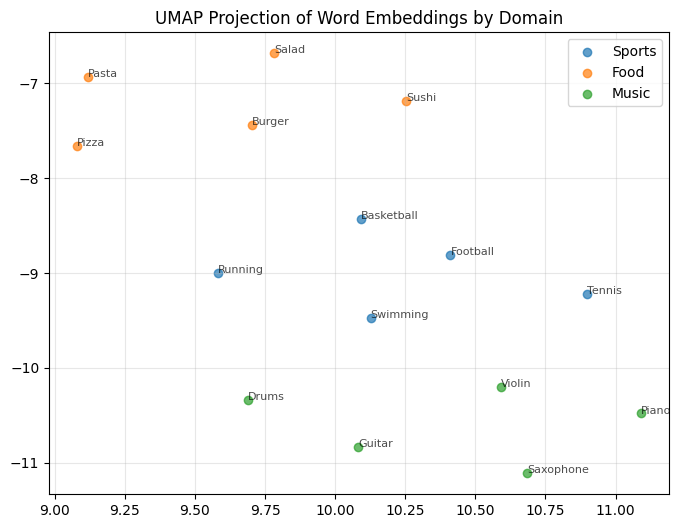

In [41]:
domains = {
    "Sports": ["Football", "Basketball", "Tennis", "Swimming", "Running"],
    "Food": ["Pizza", "Sushi", "Burger", "Pasta", "Salad"],
    "Music": ["Guitar", "Piano", "Drums", "Violin", "Saxophone"],
}

# Your code here:
# 1. Flatten the words and track their domains
all_words = []
domain_labels = []
for domain, words in domains.items():
    all_words.extend(words)
    domain_labels.extend([domain] * len(words))

# 2. Generate embeddings
embeddings = embedding_model.embed_documents(all_words)

# 3. Reduce to 2D with UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
reduced_embeddings = umap_model.fit_transform(embeddings)

# 4. Create a scatter plot with different colors per domain
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for domain in domains:
    indices = [i for i, label in enumerate(domain_labels) if label == domain]
    x_coords = [reduced_embeddings[i][0] for i in indices]
    y_coords = [reduced_embeddings[i][1] for i in indices]
    plt.scatter(x_coords, y_coords, label=domain, alpha=0.7)
plt.title("UMAP Projection of Word Embeddings by Domain")
# 5. Add labels to each point
for i, word in enumerate(all_words):
    plt.annotate(word, (reduced_embeddings[i][0], reduced_embeddings[i][1]), fontsize=8, alpha=0.7)

plt.legend()
plt.grid(visible=True, alpha=0.3)
plt.show()


/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


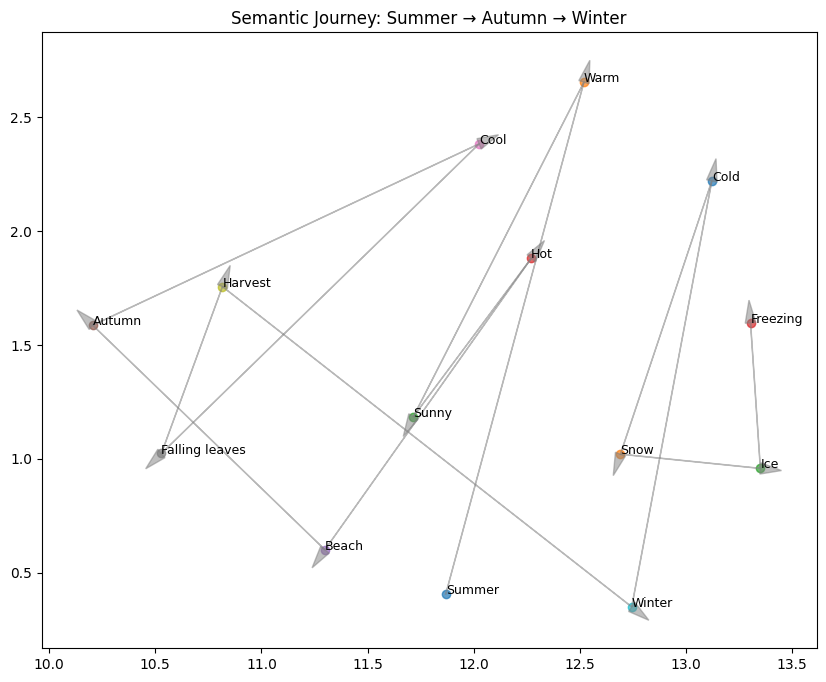

In [42]:
start_word = "Summer"
end_word = "Winter"
related_words = [
    "Summer", "Warm", "Sunny", "Hot", "Beach",
    "Autumn", "Cool", "Falling leaves", "Harvest",
    "Winter", "Cold", "Snow", "Ice", "Freezing",
]

# Your code here:
# 1. Generate embeddings for all words
embeddings = embedding_model.embed_documents(related_words)

# 2. Reduce to 2D
umap_model = umap.UMAP(n_components=2, random_state=42)
reduced_embeddings = umap_model.fit_transform(embeddings)
# 3. Create a path visualization connecting summer → autumn → winter
plt.figure(figsize=(10, 8))
for i, word in enumerate(related_words):
    plt.scatter(reduced_embeddings[i][0], reduced_embeddings[i][1], alpha=0.7)
    plt.annotate(word, (reduced_embeddings[i][0], reduced_embeddings[i][1]), fontsize=9)
plt.title("Semantic Journey: Summer → Autumn → Winter")
# 4. Use arrows to show the semantic journey
for i in range(len(related_words) - 1):
    plt.arrow(
        reduced_embeddings[i][0],
        reduced_embeddings[i][1],
        reduced_embeddings[i + 1][0] - reduced_embeddings[i][0],
        reduced_embeddings[i + 1][1] - reduced_embeddings[i][1],
        head_width=0.05,
        head_length=0.1,
        fc="gray",
        ec="gray",
        alpha=0.5,
    )
plt.show()


## 🔨 Exercise Set 4: Real-World Applications

In [39]:
faqs = {
    "How do I reset my password?": "Go to Settings > Security > Reset Password",
    "What are your shipping costs?": "Shipping is free for orders over $50",
    "How can I track my order?": "Use the tracking number sent to your email",
    "Do you accept returns?": "Yes, within 30 days with original receipt",
    "What payment methods do you accept?": "We accept credit cards, PayPal, and bank transfers",
}

def match_faq(user_question: str, faqs: dict, threshold: float = 0.7) -> tuple[str, str, float] | None:
    """Find the best matching FAQ for a user question.

    Args:
        user_question: Question from user
        faqs: Dictionary of FAQ questions and answers
        threshold: Minimum similarity to return a match

    Returns:
        Tuple of (matching_question, answer, similarity) or None

    """
    # Generate embedding for user question
    user_emb = embedding_model.embed_query(user_question)

    # Find best matching FAQ
    best_match = None
    best_similarity = -1

    for faq_question, answer in faqs.items():
        faq_emb = embedding_model.embed_query(faq_question)
        similarity = cosine_similarity(user_emb, faq_emb)

        if similarity > best_similarity:
            best_similarity = similarity
            best_match = (faq_question, answer, similarity)

    # Return match only if above threshold
    if best_similarity >= threshold:
        return best_match
    return None

# Test queries
test_queries = [
    "I forgot my password, what should I do?",
    "How much does delivery cost?",
    "Can I return items I purchased?",
    "What is the meaning of life?",  # Should not match
]

for query in test_queries:
    result = match_faq(query, faqs)
    if result:
        print(f"\nQ: {query}")
        print(f"Match: {result[0]} (similarity: {result[2]:.2f})")
        print(f"A: {result[1]}")
    else:
        print(f"\nQ: {query}")
        print("No matching FAQ found")



Q: I forgot my password, what should I do?
No matching FAQ found

Q: How much does delivery cost?
No matching FAQ found

Q: Can I return items I purchased?
No matching FAQ found

Q: What is the meaning of life?
No matching FAQ found


In [36]:
documents = [
    "The quick brown fox jumps over the lazy dog",
    "A fast brown fox leaps over a sleepy dog",  # Near-duplicate of #1
    "Python is a popular programming language",
    "The weather is nice today",
    "Python is widely used for programming",  # Near-duplicate of #3
    "The quick brown fox jumps over the lazy dog",  # Exact duplicate of #1
]

def find_duplicates(documents: list, similarity_threshold: float = 0.85) -> list[list[int]]:
    """Find groups of near-duplicate documents.

    Args:
        documents: List of text documents
        similarity_threshold: Minimum similarity to consider duplicates

    Returns:
        List of duplicate groups, each group is a list of indices

    """
    # Your code here:
    # 1. Generate embeddings
    embeddings = embedding_model.embed_documents(documents)
    # 2. Compute pairwise similarities
    n = len(embeddings)
    similarities = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            similarities[i, j] = cosine_similarity(embeddings[i], embeddings[j])
    # 3. Group documents with similarity > threshold
    visited = set()
    duplicate_groups = []
    for i in range(n):
        if i in visited:
            continue
        group = [i]
        visited.add(i)
        for j in range(i + 1, n):
            if j not in visited and similarities[i, j] > similarity_threshold:
                group.append(j)
                visited.add(j)
        if len(group) > 1:
            duplicate_groups.append(group)
    # 4. Return groups of duplicate indices
    return duplicate_groups

duplicate_groups = find_duplicates(documents)
print("Duplicate groups found:")
for i, group in enumerate(duplicate_groups, 1):
    print(f"\nGroup {i}:")
    for idx in group:
        print(f"  [{idx}] {documents[idx]}")


Duplicate groups found:

Group 1:
  [0] The quick brown fox jumps over the lazy dog
  [5] The quick brown fox jumps over the lazy dog


In [37]:
articles = [
    "Introduction to Machine Learning with Python",
    "10 Best Pasta Recipes for Beginners",
    "Understanding Neural Networks and Deep Learning",
    "How to Train Your Dog: A Complete Guide",
    "Advanced Python Programming Techniques",
    "The Ultimate Guide to Italian Cooking",
    "Cat Behavior: Understanding Your Feline Friend",
    "Building AI Applications with TensorFlow",
]

def recommend_articles(user_history: list, all_articles: list, n_recommendations: int = 3) -> list[int]:
    """Recommend articles based on reading history.

    Args:
        user_history: List of article indices the user has read
        all_articles: List of all available articles
        n_recommendations: Number of recommendations to return

    Returns:
        List of recommended article indices (excluding already read)

    """
    # Your code here:
    # 1. Get embeddings for articles in user history
    user_embeddings = embedding_model.embed_documents([all_articles[i] for i in user_history])
    # 2. Compute "user profile" (average embedding of read articles)
    user_profile = np.mean(user_embeddings, axis=0)
    # 3. Find articles most similar to user profile
    all_embeddings = embedding_model.embed_documents(all_articles)
    similarities = [cosine_similarity(user_profile, emb) for emb in all_embeddings]
    # 4. Exclude already-read articles
    recommendations = [(i, similarities[i]) for i in range(len(all_articles)) if i not in user_history]
    # 5. Return top N recommendations
    return [idx for idx, _ in sorted(recommendations, key=lambda x: x[1], reverse=True)[:n_recommendations]]

# Test: User has read articles about ML/AI
user_read = [0, 2]  # Machine Learning and Neural Networks articles
recommendations = recommend_articles(user_read, articles, n_recommendations=3)

print("User has read:")
for idx in user_read:
    print(f"  • {articles[idx]}")

print("\nRecommended articles:")
for idx in recommendations:
    print(f"  • {articles[idx]}")


User has read:
  • Introduction to Machine Learning with Python
  • Understanding Neural Networks and Deep Learning

Recommended articles:
  • Building AI Applications with TensorFlow
  • Advanced Python Programming Techniques
  • How to Train Your Dog: A Complete Guide
